# Tutorial 3.2: Evading ML-based IDS using GANs

![Status](https://img.shields.io/static/v1.svg?label=Status&message=Under_Construction&color=orange)


**Open notebook on:** 
[![View filled on Github](https://img.shields.io/static/v1.svg?logo=github&label=Repo&message=View%20On%20Github&color=lightgrey)](https://github.com/clandolt/mlcysec_notebooks/blob/main/source/tutorial_notebooks/tutorial3_1_gan_getting_started/tutorial3_1_gan_getting_started.ipynb)
[![Open filled In Collab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/clandolt/mlcysec_notebooks/blob/main/source/tutorial_notebooks/tutorial3_1_gan_getting_started/tutorial3_1_gan_getting_started.ipynb)   
**Author:** Christoph R. Landolt


As shown in Tutorial 1 and 2 have Machine Learning-based Intrusion Detection Systems (ML-IDS) significantly improved the detection of cyberattacks in modern networks. However, as defenders adopt ML models, adversaries have also begun leveraging machine learning, e.g. **Generative Adversarial Networks (GANs)**, to craft adversarial network traffic that can evade these systems while maintaining the appearance of legitimate data.

This tutorial demonstrates how adversarial techniques can be used to evade a trained ML-based IDS using the CICIDS-2017 dataset, based on the approach presented in [Zolbayar et al., “Evading Machine Learning-Based Network Intrusion Detection Systems with GANs,” 2021](https://doi.org/10.1002/9781119723950.ch17).

## Tutorial Objectives
By the end of this tutorial, you will be able to:
- Understand how adversarial machine learning applies to cybersecurity and network intrusion detection.
- Implement a simple GAN-based adversarial attack to fool a pre-trained ML-based IDS.
- Discuss defensive strategies against adversarial attacks in IDS.

## ML-Based IDS and Their Limitations

ML-based Intrusion Detection Systems (IDS) rely on classification (Tutorial 1) or anomaly detection (Tutorial 2) to separate benign from malicious network traffic. While powerful, these models have two central weaknesses that can be exploited by attackers.

1.  **Data Scarcity and Class Imbalance.** Training datasets are often heavily skewed towards benign traffic, which impacts models in different ways. For **supervised classifiers**, the lack of labeled examples means they have no way to learn about "zero-day" attacks that were unknown when the data was collected. In contrast, **anomaly detectors**, while designed to find novelty, can still miss sophisticated attacks that are crafted to appear statistically similar to benign traffic.

2.  **Adversarial Vulnerability.** Attackers can actively fool ML models by crafting malicious inputs that are designed to be misclassified as benign. This field of study is known as **Adversarial Machine Learning**. In the network domain, an adversary might slightly modify packet- or flow-level features (e.g., duration, byte/packet counts) so that malicious traffic appears statistically normal to a trained IDS. These manipulated inputs are called **adversarial examples**.

    **Example:** An attacker slightly changes packet counts or the average packet size of their traffic so that it falls within the “normal” range learned by the IDS, causing a misclassification.

    This is a critical weakness even for the anomaly-based models from Tutorial 2 (Isolation Forest, One-Class SVM, etc.). While these models strengthen detection compared to classic signature-based approaches, attackers can still probe and exploit their learned decision boundaries.

This raises a fundamental question:

> How robust are ML-based intrusion detection systems to intelligent adversaries who deliberately craft network traffic to deceive them?

### Defining Adversarial Examples
An **adversarial example** is an input to a machine learning model that has been intentionally modified in a minimal and domain-feasible way so the model makes an incorrect prediction.

Formally, let $f:\mathbb{R}^n\to\mathbb{R}^m$ be a trained classifier and let $\mathbf{x}\in\mathbb{R}^n$ be an input with true label $y^\star$ and predicted label $\hat y(\mathbf{x})=\arg\max_j f(\mathbf{x})_j$ (i.e., the class with the highest output score). An adversary seeks a perturbation $\Delta\mathbf{x}$ that is small under some norm while ensuring the perturbed input remains valid for the domain and that the model predicts a different target class $t\neq \hat y(\mathbf{x})$. A common targeted formulation is

$$\begin{align}
\min_{\Delta\mathbf{x}}\quad & c\;\|\Delta\mathbf{x}\|_{p} + \mathcal{L}\big(f(\mathbf{x}+\Delta\mathbf{x}),\,t\big) \notag \\
\text{s.t.}\quad & \mathbf{x} + \Delta\mathbf{x} \in \mathcal{C} \notag
\end{align}$$

where $\mathcal{C}$ denotes domain-specific validity constraints (e.g., integer packet counts, protocol-consistent headers, non-negativity), and $\mathcal{L}$ is an attack loss. Common norms used to measure perturbation size include:
- $\ell_0$: sparsity of modified features,
- $\ell_2$: overall magnitude,
- $\ell_\infty$: maximum per-feature change.

For *untargeted* attacks the loss $\mathcal{L}$ is replaced or modified to encourage any label different from the original prediction.

**In essence:** an adversarial example is a *malicious input disguised as normal* by making small, carefully chosen modifications that exploit the model’s decision boundary.

#### Intuition
ML models, especially complex ones, learn decision surfaces where small, carefully chosen perturbations can move an input across the boundary. In networking, this translates to:
- slight changes in packet timing or sizes,
- minor tweaks to flow statistics,
- adding or modifying benign-looking header fields,

that can cause an IDS to label malicious traffic as **benign**, producing an *evasion attack*.

#### Types of Adversarial Attacks

Attacks are typically categorized by the level of knowledge the adversary has about the target model.

<table class="tutorial-table" border="1" style="width:100%; border-collapse: collapse;">
  <thead>
    <tr>
      <th>Attack Type</th>
      <th>Knowledge Assumed by the Attacker</th>
      <th>Description</th>
    </tr>
  </thead>
  <tbody>
    <tr>
      <td><b>White-box</b></td>
      <td>Full access to model parameters, architecture, and gradients.</td>
      <td>Attacker can compute exact perturbations to fool the model. Most powerful but least realistic.</td>
    </tr>
    <tr>
      <td><b>Black-box</b></td>
      <td>No internal model knowledge; can only query inputs and observe outputs.</td>
      <td>Attacker approximates the target model by training a substitute, then crafts attacks against it. Highly practical.</td>
    </tr>
    <tr>
      <td><b>Gray-box</b></td>
      <td>Partial knowledge (e.g., model type or training data distribution).</td>
      <td>A realistic scenario between the two extremes.</td>
    </tr>
  </tbody>
</table>

GAN-based attacks typically operate under a **black-box threat model**, where the attacker has no access to the internal parameters of the target IDS. Instead, they train a **generator–discriminator framework** that learns to mimic the IDS's decision boundary. Once trained, the generator can craft adversarial traffic samples that mimic benign traffic yet successfully evade detection.

### Generative Adversarial Networks (GANs)

#### Core Concept

Generative Adversarial Networks (GANs), introduced by [Goodfellow et al. (2014)](https://arxiv.org/abs/1406.2661), consist of two competing neural networks: a **generator (G)** and a **discriminator (D)**. The generator's goal is to create synthetic data, while the discriminator's goal is to distinguish real data from the generator's fakes. Through this adversarial process, both networks improve, with the generator learning to produce increasingly realistic samples that can fool the discriminator.

GANs are increasingly applied in adversarial intrusion detection research for two key reasons:

1.  The adversarial training dynamic encourages the generator to produce **plausible and realistic modifications** to attack traffic, rather than just random noise.
2.  Their proven success in creating powerful evasion attacks in the image domain has inspired the **adaptation of GANs for network security**.

#### Mathematical Framework

The training process is a two-player minimax game defined by the objective function:

$$
\min_G \max_D V(D, G) = \mathbb{E}_{x \sim p_{\text{data}}(x)}[\log D(x)] + \mathbb{E}_{z \sim p_z(z)}[\log(1 - D(G(z)))]
$$

Let's break this down:

*   The **Discriminator (D)** wants to maximize this function. It does this by:
    1.  Maximizing the first term, $\mathbb{E}_{x \sim p_{\text{data}}(x)}[\log D(x)]$. This means it wants its output $D(x)$ to be close to 1 (high probability) for real samples $x$.
    2.  Maximizing the second term, $\mathbb{E}_{z \sim p_z(z)}[\log(1 - D(G(z)))]$. This means it wants its output $D(G(z))$ to be close to 0 (low probability) for fake samples $G(z)$.

*   The **Generator (G)** wants to minimize this function by making the second term as small as possible. It tries to make $D(G(z))$ close to 1, fooling the discriminator into thinking its fake samples are real.

Training continues until the generator produces samples that are so realistic that the discriminator is no better than random chance at telling them apart (i.e., $D(x) \approx 0.5$ for all inputs). At this equilibrium, the generator has successfully learned the underlying distribution of the real data.

#### GAN-Based Adversarial Attacks for IDS

In the context of intrusion detection, **GAN-based adversarial attacks** generate **malicious traffic designed to evade machine learning–based IDS models**. Two major variants have been applied to this problem: **IDSGAN** and **AdvGAN**.
Although both leverage the GAN framework, they differ fundamentally in how the generator alters input data and how they enforce realism or domain constraints.

### IDSGAN

[**IDSGAN** (Lin et al., 2018)](https://arxiv.org/abs/1809.02077) was designed specifically for the **network intrusion detection domain**, where data consists of structured, mixed-type features. It learns to modify malicious traffic examples so that they appear benign to a target IDS model.

- **Generator (G):** Takes a malicious traffic sample and perturbs it, aiming to preserve the attack's function while making it appear benign.
- **Discriminator (D):** Is trained as a proxy for the target IDS. Its goal is to distinguish between *real benign traffic* and the *adversarial malicious traffic* created by the generator. Its feedback teaches the generator what "benign" looks like.

**Feature Partitioning**

To maintain the validity of the attack, IDSGAN separates traffic features into two categories:

- **Immutable features** ($x_I$): Must remain unchanged to preserve the attack's core function (e.g., protocol type, service, target port).
- **Mutable features** ($x_N$): Can be adjusted to evade detection without altering the attack’s functionality (e.g., packet counts, duration).

The generator only modifies the mutable features $x_N$ to produce a new set of features, $x_N'$, creating a final adversarial sample $(x_I, x_N')$. This enforces realism but introduces a key challenge: correctly identifying which features are mutable depends heavily on the specific attack and dataset.

**Objective Function**

The IDSGAN generator's loss function is designed to fool the discriminator while minimizing changes to the original traffic:

$$
\mathcal{L}_G = \mathbb{E}_{x_{\text{mal}}} [\log(1 - D(G(x_{\text{mal}})))] + \lambda \, ||G(x_{\text{mal}}) - x_{\text{mal}}||_2
$$

- The **first term** is the adversarial loss. The generator tries to create samples $G(x_{\text{mal}})$ that the discriminator $D$ will classify as benign (i.e., making $D(G(x_{\text{mal}}))$ as high as possible), thus fooling the proxy IDS.
- The **second term** is a reconstruction penalty. It uses an $\ell_2$ norm to penalize large deviations from the original malicious sample, ensuring the adversarial example remains realistic.
- The hyperparameter $\lambda$ controls the trade-off between **evasion strength** and **traffic realism**.

<img src="./IDSGAN.jpg" alt="IDSGAN" width="800"/>

### AdvGAN

[**AdvGAN** (Xiao et al., 2018)](https://arxiv.org/abs/1801.02610), initially proposed for **image classification**, represents a **perturbation-based** adversarial framework. Unlike IDSGAN, which generates a fully modified sample, the AdvGAN generator $G$ learns to produce a subtle **perturbation vector** $\Delta x = G(x)$ that is **added** to the original input:

$$
x' = x + G(x)
$$

This design forces the adversarial sample $x'$ to remain close to the original instance while still causing misclassification. In adapting AdvGAN to network data, the perturbation must be constrained to obey domain rules (e.g., categorical features cannot be fractional).

**Loss Function**

AdvGAN's generator loss combines three components to create effective yet realistic perturbations:

$$
\mathcal{L}_G^{\text{AdvGAN}} = \mathbb{E}_x[\mathcal{L}_{\text{adv}}(f(x+G(x)), y_{\text{target}})] + \lambda \, ||G(x)||_2 + \gamma \, \mathcal{L}_{\text{GAN}}(G,D)
$$

- $\mathcal{L}_{\text{adv}}$: An **adversarial loss** that pushes the perturbed sample $x'$ towards a target class, causing the model $f$ to misclassify it.
- $||G(x)||_2$: A **perturbation norm penalty** that keeps the changes small and subtle.
- $\mathcal{L}_{\text{GAN}}$: A **realism loss** from the GAN's discriminator, which ensures that the perturbed sample $x'$ still looks like it was drawn from the original data distribution (i.e., it doesn't look like noisy, invalid traffic).

When adapted to IDS tasks, this structure allows for precise attacks that can target specific detection outcomes while maintaining valid, interpretable traffic records.

<img src="./AdvGAN.jpg" alt="AdvGAN" width="800"/>

### Comparison: IDSGAN vs. AdvGAN

The two approaches represent different philosophies in generating adversarial network traffic.

<table class="tutorial-table" border="1" style="width:100%; border-collapse: collapse;">
  <thead>
    <tr>
      <th>Aspect</th>
      <th>IDSGAN</th>
      <th>AdvGAN</th>
    </tr>
  </thead>
  <tbody>
    <tr>
      <td><b>Domain</b></td>
      <td>Network intrusion traffic</td>
      <td>Images (adaptable to tabular/network data)</td>
    </tr>
    <tr>
      <td><b>Perturbation Strategy</b></td>
      <td>Replaces a modifiable subset of features <i>x<sub>N</sub></i></td>
      <td>Learns an additive perturbation Δx to apply to the full input <i>x</i></td>
    </tr>
    <tr>
      <td><b>Core Mechanism</b></td>
      <td>Generates a full modified sample</td>
      <td>Generates only the perturbation vector</td>
    </tr>
    <tr>
      <td><b>Constraint Handling</b></td>
      <td>Manual feature partitioning (pre-generation)</td>
      <td>Post-generation masking and projection to enforce validity</td>
    </tr>
    <tr>
      <td><b>Threat Model</b></td>
      <td>Black-box (discriminator mimics IDS)</td>
      <td>Typically white-box; adaptable to black-box via transferability</td>
    </tr>
    <tr>
      <td><b>Strengths</b></td>
      <td>Domain-aware; interpretable; network-specific</td>
      <td>Highly effective; generalizable; perturbation-focused</td>
    </tr>
    <tr>
      <td><b>Weaknesses</b></td>
      <td>Depends heavily on feature engineering; can be brittle</td>
      <td>Requires careful handling of domain constraints for non-image data</td>
    </tr>
  </tbody>
</table>

### Enforcing Domain Constraints

Unlike continuous image data, **network traffic data** is structured and discrete. To craft realistic adversarial examples, we must enforce domain rules during generator training. These rules fall into two families:

1.  Enforcement of constraints on **intrinsic features** (structural constraints).
2.  Enforcement of constraints on **valid ranges** (attacker capability constraints).

#### 1. Constraints on Intrinsic Features

Some features must never be changed because they encode the attack identity or categorical information that cannot be meaningfully perturbed:

- **Attack-dependent invariants**: Certain features are fixed for a given attack type and must remain constant.
- **Protocol-dependent zeros and enums**: A protocol implies that a subset of features is always zero or only takes a restricted set of values (e.g., TCP flags, services).
- **One-hot / categorical features**: One-hot encoded categorical fields must not be perturbed (or must be projected back to a valid one-hot vector).

To enforce these rules, we mask the generator's output at every training iteration. Let the generator produce a perturbation vector
$$
\vec{\Delta x} = (\Delta x_1, \ldots, \Delta x_n)^\top,
$$
and let the binary mask vector be
$$
\vec{m} = (m_1, \ldots, m_n)^\top,\qquad m_k \in\{0,1\},
$$
where $m_k=1$ indicates the $k$-th feature is allowed to change, and $m_k=0$ indicates it must remain fixed.

The masked perturbation is the Hadamard product:
$$
\vec{\Delta x}^{\,\text{masked}} = \vec{\Delta x}\circ\vec{m},
$$
which elementwise yields $(\vec{\Delta x}\circ\vec{m})_k = m_k\,\Delta x_k$. Finally, the generator produces the candidate adversarial sample by applying the masked perturbation to the original instance $x$:
$$
x' = x + \vec{\Delta x}^{\,\text{masked}}.
$$

**Implementation notes:**
- Build $\vec{m}$ once from rules (attack type, protocol, one-hot indices). The effect is shown below:

| index | 1 | 2 | 3 | 4 | 5 | ... | n |
|---:|---:|---:|---:|---:|---:|---:|---:|
| $\Delta x$ | $\Delta x_1$ | $\Delta x_2$ | $\Delta x_3$ | $\Delta x_4$ | $\Delta x_5$ | ... | $\Delta x_n$ |
| $m$ | 1 | 0 | 1 | 0 | 1 | ... | 1 |
| masked | $\Delta x_1$ | 0 | $\Delta x_3$ | 0 | $\Delta x_5$ | ... | $\Delta x_n$ |

- For one-hot/categorical features, either set the corresponding $m_k=0$ (do not perturb) or allow a special projection step that maps the perturbed vector back to the nearest valid category.
- Masking is applied inside the generator function or immediately after its output, before any clipping or classifier evaluation.

#### 2. Constraints on Valid Ranges (Attacker Capability)

Even when a feature is mutable, its value must remain within a realistic, class-specific range. For each attack class (e.g., DoS, Probe, Benign) we compute per-feature valid intervals from the training data:
- For class `DoS` and feature $x_i$: $[d_i^{\min}, d_i^{\max}]$
- For class `Probe`: $[p_i^{\min}, p_i^{\max}]$
- For class `Benign`: $[b_i^{\min}, b_i^{\max}]$

<img src="./deception_enforcement.jpg" alt="deception_enforcement" width="600"/>

When applying a masked perturbation, we clip each feature to its class-specific valid range. Let $R_i$ denote the valid interval for feature $i$ for the current attack class; then the clipped adversarial value is:

$$
x'_i = \operatorname{clip}\big(x_i + m_i \,\Delta x_i,\; R_i^{\min},\; R_i^{\max}\big),
$$

where $\operatorname{clip}(v,a,b) = \min\{\,\max\{v,a\},\,b\}$. In vector form, this is:

$$
x' = \operatorname{clip}\big( x + (\vec{\Delta x}\circ\vec{m}),\; \vec{R}^{\min},\; \vec{R}^{\max} \big),
$$

where the clip is applied elementwise and $\vec{R}^{\min},\vec{R}^{\max}$ are the per-feature lower/upper bounds for the attack class.

**Practical procedure per training iteration:**
1.  Generator computes raw perturbation $\vec{\Delta x}$.
2.  Apply mask: $\vec{\Delta x}^{\,\text{masked}} = \vec{\Delta x}\circ\vec{m}$.
3.  Form candidate sample: $\tilde x = x + \vec{\Delta x}^{\,\text{masked}}$.
4.  Clip to valid ranges per feature/class: $x' = \operatorname{clip}(\tilde x,\; \vec{R}^{\min},\; \vec{R}^{\max})$.
5.  If any categorical features were allowed to change, project them back to the nearest valid category / one-hot vector.
6.  Feed $x'$ to the discriminator and (if applicable) to the surrogate target classifier for adversarial loss.

**Why both constraints are necessary:**
- **Masking** prevents semantic corruption (keeps attack functionality intact and respects categorical structure).
- **Clipping** enforces attacker capability limits and prevents unrealistic values that would be trivially rejected by non-ML checks.

#### Notes on computing ranges:
- Compute per-class, per-feature minima and maxima from training data (or use percentiles like 1st/99th to reduce sensitivity to outliers).
- Optionally enforce integer rounding for count-like features after clipping.
- For features with known protocol rules (flags, port ranges), apply rule-based projection rather than raw data-driven clipping.

### Key Implications and Recommended Defenses

The success of these GAN-based attacks reveals several critical insights about ML-based security:

- GAN-generated adversarial samples can **severely degrade IDS detection accuracy**.
- Such attacks often **transfer across different models**, confirming their **black-box evasion** potential.
- The success of these methods highlights the **fragility of data-driven IDS boundaries**, which often rely on non-causal statistical correlations rather than a true understanding of threats.
- Under adaptive threats, even IDS models with high static accuracy can **fail catastrophically**.

This underscores the urgent need for more robust defense strategies, including:

- **Adversarial Training:** Augmenting training data with generated adversarial examples to make models more resilient.
- **Model Ensembles:** Combining diverse models to create a more complex and harder-to-evade decision boundary.
- **Input Sanitization:** Pre-processing pipelines to detect and reject or normalize anomalous-looking inputs before they reach the model.
- **Causal and Invariant Feature Engineering:** Designing features that are causally linked to malicious activity and invariant to the simple perturbations used in evasion attacks.


## 2. AdvGAN Implementation
GAN components and intuition

A **Generative Adversarial Network (GAN)** consists of two competing neural networks:

<table class="tutorial-table" border="1" style="width:100%; border-collapse: collapse;">
  <thead>
    <tr>
      <th>Component</th>
      <th>Role</th>
      <th>Analogy</th>
    </tr>
  </thead>
  <tbody>
    <tr>
      <td><b>Generator (G)</b></td>
      <td>Creates fake (adversarial) samples from noise or modified real data.</td>
      <td>Counterfeiter producing fake currency.</td>
    </tr>
    <tr>
      <td><b>Discriminator (D)</b></td>
      <td>Attempts to distinguish between real (benign) and fake (adversarial) samples.</td>
      <td>Police trying to detect counterfeits.</td>
    </tr>
  </tbody>
</table>


Both networks are trained **in opposition**:

- **G** improves at creating more convincing fakes.  
- **D** improves at spotting them.

The goal is for **G** to generate adversarial examples that the IDS (analogous to **D**) misclassifies as **benign**.


### Step 1: Load and Explore the CICIDS-2017 Dataset
- Downloading the dataset from Kaggle (if not already available)
- Loading parquet files from multiple attack types
- Cleaning, merging, and preparing the final binary classification dataset (Benign vs Attack)





In [1]:
import os
import pandas as pd
import numpy as np
from glob import glob
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Dataset parameters
FILE = "cicids2017.zip"
DIR = "cicids2017"
URL = "https://www.kaggle.com/api/v1/datasets/download/dhoogla/cicids2017"

# Download if not exists
if not os.path.isfile(FILE):
    print(f"📥 Downloading {FILE} from Kaggle...")
    !curl -L -o {FILE} {URL}
else:
    print(f"✅ {FILE} already exists, skipping download.")

# Unzip if not exists
if not os.path.isdir(DIR):
    print(f"📦 Unzipping {FILE}...")
    !unzip -q {FILE} -d {DIR}
else:
    print(f"✅ {DIR} already exists, skipping unzip.")

✅ cicids2017.zip already exists, skipping download.
✅ cicids2017 already exists, skipping unzip.


**Load and Merge Data Files:**
Load the CICIDS2017 parquet files by attack category and combine them into a single DataFrame.


In [2]:
import os
import pandas as pd
import numpy as np

# 🔍 Display available files (from local directory)
DATA_DIR = "./cicids2017"   # ← adjust this if your folder name/path differs

for dirname, _, filenames in os.walk(DATA_DIR):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# 📂 Load Parquet data files by attack type (local paths)
df_data_1 = pd.read_parquet(os.path.join(DATA_DIR, 'Benign-Monday-no-metadata.parquet'))
df_data_2 = pd.read_parquet(os.path.join(DATA_DIR, 'Bruteforce-Tuesday-no-metadata.parquet'))
df_data_3 = pd.read_parquet(os.path.join(DATA_DIR, 'Portscan-Friday-no-metadata.parquet'))
df_data_4 = pd.read_parquet(os.path.join(DATA_DIR, 'WebAttacks-Thursday-no-metadata.parquet'))
df_data_5 = pd.read_parquet(os.path.join(DATA_DIR, 'DoS-Wednesday-no-metadata.parquet'))
df_data_6 = pd.read_parquet(os.path.join(DATA_DIR, 'DDoS-Friday-no-metadata.parquet'))
df_data_7 = pd.read_parquet(os.path.join(DATA_DIR, 'Infiltration-Thursday-no-metadata.parquet'))
df_data_8 = pd.read_parquet(os.path.join(DATA_DIR, 'Botnet-Friday-no-metadata.parquet'))

# 🧩 Concatenate all data into a single DataFrame
df_data = pd.concat([
    df_data_1, df_data_2, df_data_3, df_data_4,
    df_data_5, df_data_6, df_data_7, df_data_8
], axis=0, ignore_index=True)

print("✅ Combined dataset shape:", df_data.shape)
df_data.head()


./cicids2017/DDoS-Friday-no-metadata.parquet
./cicids2017/Bruteforce-Tuesday-no-metadata.parquet
./cicids2017/Botnet-Friday-no-metadata.parquet
./cicids2017/DoS-Wednesday-no-metadata.parquet
./cicids2017/Benign-Monday-no-metadata.parquet
./cicids2017/Infiltration-Thursday-no-metadata.parquet
./cicids2017/Portscan-Friday-no-metadata.parquet
./cicids2017/WebAttacks-Thursday-no-metadata.parquet
✅ Combined dataset shape: (2313810, 78)


,Protocol,Flow Duration,Total Fwd Packets,Total Backward Packets,Fwd Packets Length Total,Bwd Packets Length Total,Fwd Packet Length Max,Fwd Packet Length Min,Fwd Packet Length Mean,Fwd Packet Length Std,...,Fwd Seg Size Min,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min,Label
0,6,4,2,0,12,0,6,6,6.00000,0.000000,...,20,0.0,0.0,0,0,0.0,0.0,0,0,Benign
1,6,1,2,0,12,0,6,6,6.00000,0.000000,...,20,0.0,0.0,0,0,0.0,0.0,0,0,Benign
2,6,3,2,0,12,0,6,6,6.00000,0.000000,...,20,0.0,0.0,0,0,0.0,0.0,0,0,Benign
3,6,1,2,0,12,0,6,6,6.00000,0.000000,...,20,0.0,0.0,0,0,0.0,0.0,0,0,Benign
4,6,609,7,4,484,414,233,0,69.14286,111.967896,...,20,0.0,0.0,0,0,0.0,0.0,0,0,Benign


**Data Cleaning and Preprocessing:**
Handle missing values, infinite values, and duplicates.


In [3]:
# Select only numeric columns for model input
df_numeric = df_data.select_dtypes(include=[np.number])

# Identify infinite values
infinity_counts = np.isinf(df_numeric).sum()
print("♾️ Infinite value counts per column:\n", infinity_counts[infinity_counts > 0])

# Replace infinities with NaN and drop missing values
df_numeric = df_numeric.replace([np.inf, -np.inf], np.nan)
df_numeric = df_numeric.dropna()

# Drop duplicate rows
duplicates = df_data.duplicated().sum()
print(f"🧹 Found and removing {duplicates} duplicate rows...")
df_data = df_data.drop_duplicates()

print("✅ Cleaned dataset shape:", df_data.shape)


♾️ Infinite value counts per column:
 Series([], dtype: int64)
🧹 Found and removing 82004 duplicate rows...
✅ Cleaned dataset shape: (2231806, 78)


**Prepare Features and Labels:**
Convert multi-class attack labels into binary labels (0 = Benign, 1 = Attack).


In [4]:
# Separate features and labels
X = df_data.copy()
X = X.drop(columns='Label') 
y = df_data["Label"].copy()

# Binary encode labels: 0 = Benign, 1 = Attack
y_b = y.map({'Benign': 0}).fillna(1).astype(int).rename('Label')

# Create final binary-labeled DataFrame
df_binary = X.copy()
df_binary['Label'] = y_b

print("✅ Final dataset shape:", df_binary.shape)
print(df_binary['Label'].value_counts())


✅ Final dataset shape: (2231806, 78)
Label
0    1895314
1     336492
Name: count, dtype: int64


**Feature Scaling and Train-Test Split:**
Normalize features and prepare for model training and evaluation.


In [5]:
# Separate features and target
X = df_binary.drop(columns=['Label'])
y = df_binary['Label']

# Scale features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Train-test split (80/20)
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42, stratify=y
)

print("✅ Training samples:", len(X_train))
print("✅ Testing samples:", len(X_test))
print("📊 Attack ratio:", y.mean())


✅ Training samples: 1785444
✅ Testing samples: 446362
📊 Attack ratio: 0.1507711691786831


**Notes:**
- CICIDS-2017 provides realistic network flow features (e.g., duration, packet length, byte count, flow rate).
- We standardize all numeric features since GANs and neural networks require normalized inputs for stable training.

### Step 2: Train a Baseline IDS Classifier
We’ll use a simple Multi-Layer Perceptron (MLP) as our ML-based IDS.

In [6]:
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import classification_report, confusion_matrix

# Train baseline IDS
ids = MLPClassifier(hidden_layer_sizes=(64, 32), activation='relu', max_iter=50, random_state=42)
ids.fit(X_train, y_train)

# Evaluate baseline accuracy
y_pred = ids.predict(X_test)
print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))


[[378722    341]
 [  1257  66042]]
              precision    recall  f1-score   support

           0       1.00      1.00      1.00    379063
           1       0.99      0.98      0.99     67299

    accuracy                           1.00    446362
   macro avg       1.00      0.99      0.99    446362
weighted avg       1.00      1.00      1.00    446362



/Users/christophlandolt/.pyenv/versions/mlcysec25/lib/python3.12/site-packages/sklearn/neural_network/_multilayer_perceptron.py:781: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (50) reached and the optimization hasn't converged yet.
  warnings.warn(


**Discussion:**
This model represents a standard supervised ML-IDS.
Next, we’ll attempt to fool this classifier by generating adversarial samples.

### Step 3: Design a Simple GAN for Evasion Attacks

We now build a Generator to create adversarial variants of malicious samples that appear “benign” to the IDS.

In [7]:
import torch
import torch.nn as nn
import torch.optim as optim

input_dim = X_train.shape[1]

class Generator(nn.Module):
    def __init__(self):
        super().__init__()
        self.model = nn.Sequential(
            nn.Linear(input_dim, 128),
            nn.ReLU(),
            nn.Linear(128, input_dim),
            nn.Tanh()
        )
    def forward(self, x):
        return self.model(x)

class Discriminator(nn.Module):
    def __init__(self):
        super().__init__()
        self.model = nn.Sequential(
            nn.Linear(input_dim, 128),
            nn.ReLU(),
            nn.Linear(128, 1),
            nn.Sigmoid()
        )
    def forward(self, x):
        return self.model(x)

G = Generator()
D = Discriminator()

criterion = nn.BCELoss()
opt_G = optim.Adam(G.parameters(), lr=0.001)
opt_D = optim.Adam(D.parameters(), lr=0.001)


### Step 4: Train the GAN

We’ll train on malicious samples only and encourage the generator to produce adversarial versions that the IDS misclassifies as benign.

In [8]:
malicious = torch.tensor(X_train[y_train == 1], dtype=torch.float)
benign = torch.tensor(X_train[y_train == 0], dtype=torch.float)

for epoch in range(50):
    for _ in range(5):
        # Train discriminator
        opt_D.zero_grad()
        real_labels = torch.ones(len(benign), 1)
        fake_labels = torch.zeros(len(malicious), 1)
        fake_data = G(malicious)
        outputs_real = D(benign)
        outputs_fake = D(fake_data.detach())
        d_loss = criterion(outputs_real, real_labels) + criterion(outputs_fake, fake_labels)
        d_loss.backward()
        opt_D.step()

    # Train generator
    opt_G.zero_grad()
    fake_data = G(malicious)
    outputs = D(fake_data)
    g_loss = criterion(outputs, torch.ones_like(outputs))
    g_loss.backward()
    opt_G.step()

    if epoch % 10 == 0:
        print(f"Epoch {epoch}: D Loss={d_loss.item():.4f}, G Loss={g_loss.item():.4f}")


Epoch 0: D Loss=1.2356, G Loss=0.7324
Epoch 10: D Loss=0.6763, G Loss=1.0217
Epoch 20: D Loss=0.3225, G Loss=2.0411
Epoch 30: D Loss=0.1408, G Loss=2.8961
Epoch 40: D Loss=0.0762, G Loss=4.1635


### Step 5: Evaluate Evasion Effectiveness

We’ll generate adversarial attack traffic and test whether it fools the trained IDS.

In [9]:
# Generate adversarial samples
G.eval()
adv_samples = G(torch.tensor(X_test[y_test == 1], dtype=torch.float)).detach().numpy()

# IDS predictions on original vs. adversarial attacks
orig_preds = ids.predict(X_test[y_test == 1])
adv_preds = ids.predict(adv_samples)

orig_acc = np.mean(orig_preds == 1)
adv_acc = np.mean(adv_preds == 1)

print(f"Detection rate on original attacks: {orig_acc:.2%}")
print(f"Detection rate on adversarial attacks: {adv_acc:.2%}")
print(f"Evasion success: {100 * (orig_acc - adv_acc):.2f}% reduction in detection.")


Detection rate on original attacks: 98.13%
Detection rate on adversarial attacks: 0.01%
Evasion success: 98.12% reduction in detection.


### Visualization

You can visualize the feature shifts between original and adversarial samples using PCA:

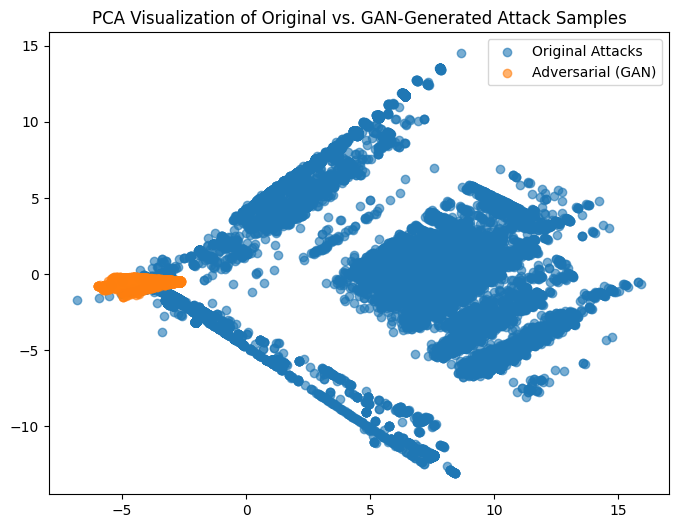

In [10]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

pca = PCA(n_components=2)
reduced = pca.fit_transform(np.vstack([X_test[y_test==1], adv_samples]))
labels = np.array([0]*len(X_test[y_test==1]) + [1]*len(adv_samples))

plt.figure(figsize=(8,6))
plt.scatter(reduced[labels==0,0], reduced[labels==0,1], label='Original Attacks', alpha=0.6)
plt.scatter(reduced[labels==1,0], reduced[labels==1,1], label='Adversarial (GAN)', alpha=0.6)
plt.title('PCA Visualization of Original vs. GAN-Generated Attack Samples')
plt.legend()
plt.show()


### Exercises – GAN-Based Evasion

**Exercise 1: Attack Success vs. Perturbation Strength**  
Adjust the generator’s learning rate or noise level and observe how it affects evasion success.

**Exercise 2: Constrained GANs**  
Implement feature constraints to ensure generated samples remain valid (e.g., no negative packet counts).

**Exercise 3: Compare Models**  
Train alternative IDS classifiers (Random Forest, CNN) and compare adversarial robustness.

**Exercise 4: Evaluate Transferability**  
Test whether adversarial samples crafted for one IDS (e.g., MLP) can fool another (e.g., SVM).


## Conclusion
In this tutorial, we replicated the core idea from **Zolbayar et al. (2021):**  
> GANs can be used to craft adversarial network traffic capable of evading ML-based IDS.

By training a generator to produce **constrained adversarial features**, we demonstrated:

- IDS models are **vulnerable to subtle perturbations**.  
- **Adversarial samples** can significantly reduce detection rates.  
- **Defensive retraining** and **ensemble methods** are necessary to mitigate such attacks.

This highlights the **arms race** between attackers and defenders in the **ML-driven cybersecurity domain**.


---

[![Star our repository](https://img.shields.io/static/v1.svg?logo=star&label=⭐&message=Star%20Our%20Repository&color=yellow)](https://github.com/clandolt/mlcysec_notebooks/)  If you found this tutorial helpful, please **⭐ star our repository** to show your support.   
[![Ask questions](https://img.shields.io/static/v1.svg?logo=star&label=❔&message=Ask%20Questions&color=9cf)](https://github.com/clandolt/mlcysec_notebooks/issues)  For any **questions**, **typos**, or **bugs**, kindly open an issue on GitHub — we appreciate your feedback!

---